Part 1: Multicollinearity and Multiple Linear Regression

1. [2 pts] Last week, in Part 4b, I asked you to compare three models predicting penguin body mass 
and based on the R², adjusted R², RSE, and the F-statistic, I asked you to explain which model 
you would choose, and why. Given the techniques we discussed in Week 4 in class, how would 
you determine which model is better? Does your answer change from what you listed in last 
week’s homework? 

ANSWER: From Part 4b, I would choose Model 3 because R^2 and adjusted R² increased while the residual standard error decreased. During class we discussed that we can determine which models are better by calculating their variance and comparing them to each other (F-test). We can calculate this by getting the variance of each predictors for each model then comparing thr values. The smaller the value of the variance the less variance in the data. From this, I would say that it didn't change my decision of which model is the best (model 3) since that model holds the smallest variance.

In [91]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.anova import anova_lm

In [92]:
# Hello again Penguins 
peng = pd.read_csv("../data/penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)

print(f"n = {len(peng)}")
peng.head()

n = 342


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [93]:
#Varince Inflation Factor for each of these regressors

preds = ["flipper_length_mm",
        "flipper_length_mm + bill_depth_mm",
        "flipper_length_mm + bill_depth_mm + bill_length_mm"]

def vif_table(df, cols):
    X = sm.add_constant(df[cols])
    return pd.DataFrame({
        "variable": cols,
        "VIF": [variance_inflation_factor(X.values, X.columns.get_loc(c)) for c in cols],
    }).round(2)

vif_table(peng, preds)

KeyError: "['flipper_length_mm + bill_depth_mm', 'flipper_length_mm + bill_depth_mm + bill_length_mm'] not in index"

2. In class, when looking at the bike data, we showed that temp and atemp (“feels like”) 
temp are highly correlated, but we didn’t explicitly check the correlation of other variables in our 
model. Now switch to the bike data. For this question, we want to explicitly look at cnt ~ temp + 
hum + windspeed?

2a: Look at the correlation matrix for all of these variables. In addition to the .corr() 
function, use the sm.heatmap() function for an equivalent visual.

In [ ]:
bike = pd.read_csv("../data/bike-sharing-daily.csv", parse_dates=["dteday"])
print(bike.shape)
print(bike.dtypes)
bike.head()

(731, 16)
instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


             instant    season        yr      mnth   holiday   weekday  \
instant     1.000000  0.412224  0.866025  0.496702  0.016145 -0.000016   
season      0.412224  1.000000 -0.001844  0.831440 -0.010537 -0.003080   
yr          0.866025 -0.001844  1.000000 -0.001792  0.007954 -0.005461   
mnth        0.496702  0.831440 -0.001792  1.000000  0.019191  0.009509   
holiday     0.016145 -0.010537  0.007954  0.019191  1.000000 -0.101960   
weekday    -0.000016 -0.003080 -0.005461  0.009509 -0.101960  1.000000   
workingday -0.004337  0.012485 -0.002013 -0.005901 -0.253023  0.035790   
weathersit -0.021477  0.019211 -0.048727  0.043528 -0.034627  0.031087   
temp        0.150580  0.334315  0.047604  0.220205 -0.028556 -0.000170   
atemp       0.152638  0.342876  0.046106  0.227459 -0.032507 -0.007537   
hum         0.016375  0.205445 -0.110651  0.222204 -0.015937 -0.052232   
windspeed  -0.112620 -0.229046 -0.011817 -0.207502  0.006292  0.014282   
casual      0.275255  0.210399  0.2485

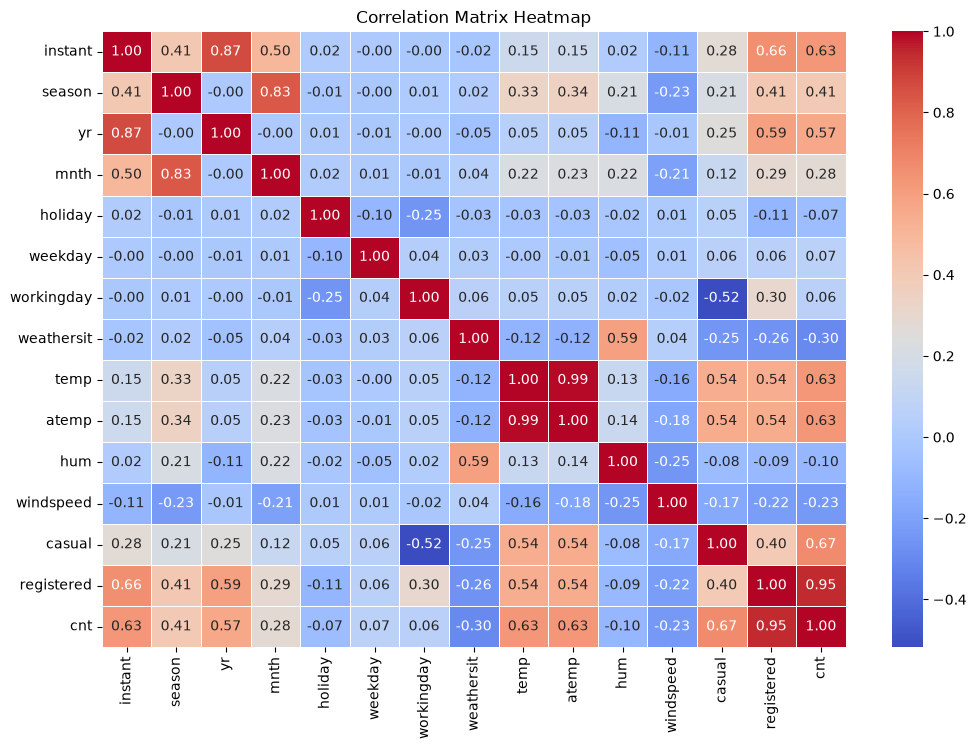

In [ ]:
#correlation matrix
corr_matrix = bike.corr(numeric_only=True)
print(corr_matrix)

#sm.heatmap()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

2b: [2 pts] Build a linear model as we did in class predicting cnt ~ tmp + hum + windspeed. 
Calculate the VIF for each of these features. For each feature (temp, hum, windspeed) 
describe how it impacts the count of bikes rented. Does this match your intuition? 

ANSWER: Each feature shows that they're independent from one another, which does match my intuition.

In [ ]:
#Linear model

model = smf.ols('cnt ~ temp + hum + windspeed', data=bike).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.26e-97
Time:                        19:23:21   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4084.3634    337.862     12.089      0.0

In [ ]:
#Varince Inflation Factor for each of these regressors

preds = ["temp", "hum", "windspeed"]
def vif_table(df, cols):
    X = sm.add_constant(df[cols])
    return pd.DataFrame({
        "variable": cols,
        "VIF": [variance_inflation_factor(X.values, X.columns.get_loc(c)) for c in cols],
    }).round(2)

vif_table(bike, preds)

,variable,VIF
0,temp,1.03
1,hum,1.07
2,windspeed,1.08


2c: [2 pts] Build three models for count and use the nested F-test to compare them. Although 
we did not do this explicitly in class, the anova_lm function will accept three models as 
arguments.
i. cnt ~ tmp 
ii. cnt ~tmp + hum 
iii. cnt ~ tmp + hum + windspeed 

In [ ]:
#i. cnt ~ tmp 
model1 = smf.ols("cnt ~ temp", data=bike).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     473.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           2.81e-81
Time:                        19:37:21   Log-Likelihood:                -6386.8
No. Observations:                 731   AIC:                         1.278e+04
Df Residuals:                     729   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1214.6421    161.164      7.537      0.0

In [ ]:
#ii. cnt ~tmp + hum 
model2 = smf.ols("cnt ~ temp + hum", data=bike).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     271.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.06e-88
Time:                        19:38:04   Log-Likelihood:                -6366.3
No. Observations:                 731   AIC:                         1.274e+04
Df Residuals:                     728   BIC:                         1.275e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2657.8951    272.423      9.757      0.0

In [ ]:
#iii. cnt ~ tmp + hum + windspeed 
model3 = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.26e-97
Time:                        19:38:24   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4084.3634    337.862     12.089      0.0

In [ ]:
#F-test to compare them using anova_lm function
anova_results = anova_lm(model1, model2, model3)
print(anova_results)

   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     729.0  1.660847e+09      0.0           NaN        NaN           NaN
1     728.0  1.570304e+09      1.0  9.054330e+07  44.569779  4.869005e-11
2     727.0  1.476897e+09      1.0  9.340630e+07  45.979085  2.475445e-11


2d: [2 pts] Of these three models, which model would you choose and why?

ANSWER: I would chose the  model 3 because it shows the lowest SSR (1.47e+09) compared to the other two models. 

Side Note: Use of AI for question 2
I used GenAI to help explain concepts, VIF, by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

Part 2: Categorical Predictors and Interaction Terms (15 pts) For the first part of this section, we will be looking at the penguin data with sex as a categorical variable. 
This means you will need to modify the penguin dataset to drop the penguins where sex is missing. 

1. [3 pts] Fit body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm with the new 
dataset (e.g. with additional penguins removed where sex is missing). Compare the output of this 
regression with the one you did previously where the penguins where sex is missing were not 
removed. Does removing these penguins change anything about the model?

ANSWER: Removing these penguins does change the model by adjusting the the dataset size/focus. The previously made regression model demonstrates lower values than the one presented in the new model. 

In [ ]:
#Dataset with drop the peng where sex is missing
penguins = sns.load_dataset('penguins').dropna(subset=['sex'])

#New data set
model_no_missing = smf.ols(
    'body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm', 
    data=penguins
).fit()

print(model_no_missing.summary()) 


                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.26e-103
Time:                        22:00:19   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6445.4760    566.13

2. [3 pts] Fit an additive model for body_mass_g ~ flipper_length_mm + C(sex) as well as an 
interactive model. Compare these two models with the model that only includes flipper_length.  
a. Which of the three models is the best and why? How did you come to this decision?  
The best model is the additive model (model 2) because by adding sex, it improves the flipper only model (F = 74.1, p ≈ 3e-16), while adding the interaction does not (F = 0.010, p = 0.92).

b. What is the impact of sex on the prediction of body mass? How do male and female 
penguins differ?  
When including sex for the prediction of body mass, it becomes more accurate because sex explains the body mass variation that flipper length cannot. The male and female penguin differ by a constant offset in body mass of 348 g heavier than females.

c. Include at least one plot and explain how you used it to help you answer this question. 
It shows a plot for each sex. I used this line compare and see that female vs males. it shows that males are heavier at the same flipper length, to show an interaction between flipper length and body mass.


#Part 2 question 2a/2b

In [ ]:
#Additive model
model2 = smf.ols('body_mass_g ~ flipper_length_mm + C(sex)', data=penguins).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          3.53e-118
Time:                        22:29:32   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.79

In [ ]:
#Interactive model
model3 = smf.ols('body_mass_g ~ flipper_length_mm * C(sex)', data=penguins).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     455.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.04e-116
Time:                        22:30:01   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4862.
Df Residuals:                     329   BIC:                             4878.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:
#Flipper only model
model1 = smf.ols('body_mass_g ~ flipper_length_mm', data=penguins).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          3.13e-105
Time:                        22:31:59   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5872.0927    310.28

In [ ]:
#comparision
anova_results = anova_lm(model1, model2, model3)
print(anova_results)

   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     331.0  5.121196e+07      0.0           NaN        NaN           NaN
1     330.0  4.179537e+07      1.0  9.416589e+06  74.126700  3.050629e-16
2     329.0  4.179409e+07      1.0  1.286001e+03   0.010123  9.199177e-01


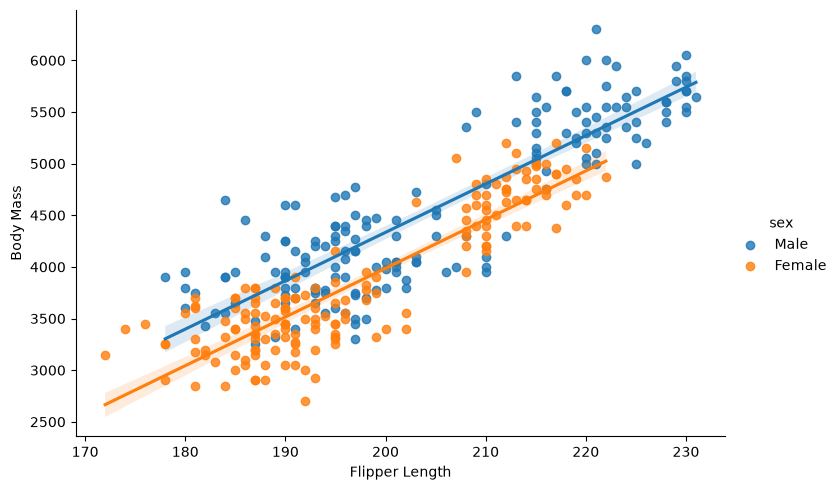

In [ ]:
#Part 2 question 2c
#plot male vs female
sns.lmplot(
    data=penguins, 
    x='flipper_length_mm', 
    y='body_mass_g', 
    hue='sex', 
    aspect=1.5
)
plt.xlabel('Flipper Length')
plt.ylabel('Body Mass')
plt.show()

3. [3 pts] Fit additive and interactive models for body_mass_g using only sex and species as predictors.  

a. Which model is better? 
The interaction model is better because the nested F-test is significant and it has a higher adjusted r^2. 

b. How would you interpret the coefficients in this case?
The intercept is the mean mass of female Adelie penguins, the sex and species coefficients are effects within that reference group only, and the interaction terms show how the male-female gap differs from Adelie's 675 g, shrinking by 263 g in Chinstrap and growing by 130 g in Gentoo.   

c. Include at least one plot and explain how you used it to help interpret this model. 
The plot shows the male-female gap differs by species which is what the interaction captures and why the additive model's single sex is worse.

In [ ]:
#Part 2 question 3a:
#additive model
model_add = smf.ols('body_mass_g ~ C(sex) + C(species)', data=penguins).fit()
print(model_add.summary())


                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     606.1
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.27e-133
Time:                        22:48:21   Log-Likelihood:                -2387.8
No. Observations:                 333   AIC:                             4784.
Df Residuals:                     329   BIC:                             4799.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3

In [ ]:
#Part 2 question 3a:
#interactive model
model_int = smf.ols('body_mass_g ~ C(sex) * C(species)', data=penguins).fit()
print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     384.3
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.54e-134
Time:                        22:48:53   Log-Likelihood:                -2379.1
No. Observations:                 333   AIC:                             4770.
Df Residuals:                     327   BIC:                             4793.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [ ]:
#Part 2 question 3a:
#comparison
anova_comp = anova_lm(model_add, model_int)
print(anova_comp)

   df_resid           ssr  df_diff       ss_diff         F    Pr(>F)
0     329.0  3.297919e+07      0.0           NaN       NaN       NaN
1     327.0  3.130263e+07      2.0  1.676557e+06  8.756997  0.000197


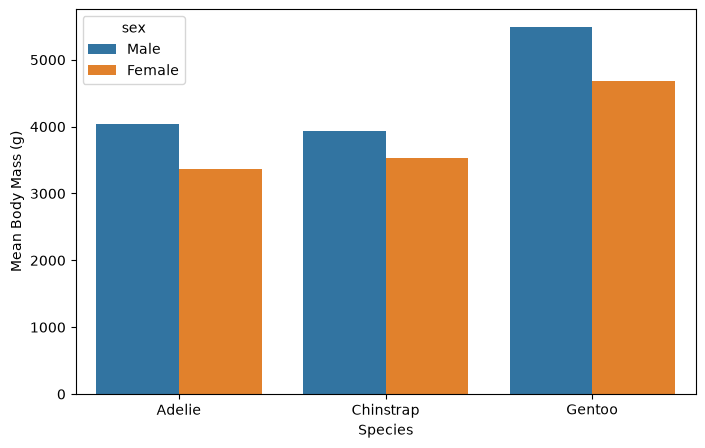

In [ ]:
#Part 2 question 3c:
#Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=penguins, 
    x='species', 
    y='body_mass_g', 
    hue='sex', 
    errorbar=None
)
plt.xlabel('Species')
plt.ylabel('Mean Body Mass (g)')
plt.show()

4. [6 pts] In class, we predicted count of bike rentals with working day as a categorical predictor to 
identify if there was a significant interaction with temperature. (We found there was not.) Now 
we are going to look at casual and registered users separately.  

Part 2 4a:Fit a model: casual ~ temp + C(workingday) + hum + windspeed. Then build a second model that includes the interaction between temp and working day. Compare these two models. Which is better?  

The interaction model is better because the F-test p <0.001 and the adj R^2 goesf rom .627 to .677. The additive model is enough because the F-test p = .098 meaning the interaction is not significant, The adj. R^2 barley changes as well

In [ ]:
#4A
#additive model
casual_add = smf.ols(
    'casual ~ temp + C(workingday) + hum + windspeed', 
    data=bike
).fit()

print(casual_add.summary())

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     307.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.84e-155
Time:                        22:59:03   Log-Likelihood:                -5448.9
No. Observations:                 731   AIC:                         1.091e+04
Df Residuals:                     726   BIC:                         1.093e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1063.5527    101

In [ ]:
#4A
#interactive model for casual users
casual_int = smf.ols(
    'casual ~ temp * C(workingday) + hum + windspeed', 
    data=bike
).fit()

print(casual_int.summary())

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     307.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          2.25e-176
Time:                        23:00:01   Log-Likelihood:                -5395.6
No. Observations:                 731   AIC:                         1.080e+04
Df Residuals:                     725   BIC:                         1.083e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [ ]:
# Comparasion
anova_casual = anova_lm(casual_add, casual_int)
print(anova_casual)

   df_resid           ssr  df_diff       ss_diff           F        Pr(>F)
0     726.0  1.276423e+08      0.0           NaN         NaN           NaN
1     725.0  1.103186e+08      1.0  1.732378e+07  113.849712  8.681452e-25


Part 2 4b: b. Repeat part a) but with registered instead of casual as the thing you are predicting.  

In [ ]:
#additive model
reg_add = smf.ols(
    'registered ~ temp + C(workingday) + hum + windspeed', 
    data=bike
).fit()

print(reg_add.summary())

                            OLS Regression Results                            
Dep. Variable:             registered   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     134.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           5.97e-86
Time:                        23:03:59   Log-Likelihood:                -6208.8
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     726   BIC:                         1.245e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2945.8161    286

In [ ]:
#interactive model
reg_int = smf.ols(
    'registered ~ temp * C(workingday) + hum + windspeed', 
    data=bike
).fit()

print(reg_int.summary())

                            OLS Regression Results                            
Dep. Variable:             registered   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     108.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.89e-85
Time:                        23:04:15   Log-Likelihood:                -6207.4
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     725   BIC:                         1.245e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3

In [ ]:
#comparison
anova_reg = anova_lm(reg_add, reg_int)
print(anova_reg)

   df_resid           ssr  df_diff       ss_diff         F   Pr(>F)
0     726.0  1.020706e+09      0.0           NaN       NaN      NaN
1     725.0  1.016851e+09      1.0  3.855347e+06  2.748806  0.09776


Part 2 4c. Interpret the results for a and b. What is this data telling you. 

Based on the two models, casual riders rent more on non-working days and respond better to warm days. Registered riders rent more on working days, and response is not dependent on weather.

Part 2 4d: Why did I ask you to build two separate models vs adding either of these variables into 
our original model? 

Since casual and registered riders behave differently, their effect will naturally go in opposite directions. If we were to put it into a combined model, the effects will cancer and get hidden. Thus, it is better to separate the models to show the patterns clearly.


Side Note: Use of AI for PART 2
I used GenAI to help explain concepts, addictive model, interactive model, and ANOVA comparison, by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

Part 3: Outliers, Leverage, and Influence (12 pts) 

1) [8 pts] In part 2 above, we removed 9 penguins from the data set in order to look at sex as a 
predictor variable. Using the original model predicting body_mass_g ~ flipper_length_mm + 
bill_depth_mm + bill_length_mm (n=342) do the following: 

1a: Build a DataFrame, similar to the one we did in class, that contains the following for each 
penguin: actual body mass, predicted body mass, studentized residuals, leverage, and 
Cook’s distance. 

In [ ]:
#data set laoding
peng = pd.read_csv("../data/penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)

print(f"n = {len(peng)}")
peng.head()

n = 342


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [ ]:
#OLS model
orig_model = smf.ols(
    'body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm', 
    data=peng
).fit()

#OLS influence diagnostics
new = orig_model.get_influence()

In [ ]:
model = smf.ols("cnt ~ temp + hum + windspeed + C(season) + C(weathersit)", data=bike).fit()
infl = OLSInfluence(model) # Class that calculates outlier and influence measures for an OLS result

n, p = int(model.nobs), model.df_model
print(f"n = {n}, p = {p:.0f} ")
print(model.summary())

n = 731, p = 8 
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     113.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          5.27e-122
Time:                        23:54:45   Log-Likelihood:                -6272.6
No. Observations:                 731   AIC:                         1.256e+04
Df Residuals:                     722   BIC:                         1.260e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           

In [ ]:
#dataframe
diag = pd.DataFrame({
    "date":      bike.dteday,
    "cnt":       bike.cnt,
    "fitted":    model.fittedvalues,
    "residuals": model.resid,
    "student_resid": infl.resid_studentized_external,
    "leverage":  infl.hat_matrix_diag,
    "cooks_d":   infl.cooks_distance[0],
})

diag.head(10)

,date,cnt,fitted,residuals,student_resid,leverage,cooks_d
0,2011-01-01,985,2387.948181,-1402.948181,-1.086938,0.010072,0.001335
1,2011-01-02,801,2503.560803,-1702.560803,-1.319008,0.009224,0.001798
2,2011-01-03,1349,2368.102043,-1019.102043,-0.788576,0.008389,0.000585
3,2011-01-04,1562,2280.209969,-718.209969,-0.555898,0.009356,0.000325
4,2011-01-05,1600,2763.317015,-1163.317015,-0.900206,0.008212,0.000746
5,2011-01-06,1606,2732.970861,-1126.970861,-0.873764,0.012094,0.001039
6,2011-01-07,1510,2253.529586,-743.529586,-0.576795,0.013784,0.000517
7,2011-01-08,959,1633.383671,-674.383671,-0.522633,0.011896,0.000366
8,2011-01-09,822,1637.667040,-815.667040,-0.633113,0.014803,0.000670
9,2011-01-10,1321,2048.693737,-727.693737,-0.563282,0.009498,0.000338


1b: Report the cutoffs we used in class and identify the number of penguins that exceed each 
cutoff, if any. Pay particular attention to the 9 penguins that are missing the sex variable. 
Do any of them exceed any of these cutoffs?  

ANSWER: none of the penguins exceed the cutoff

In [ ]:
# Now let's look at the cutoff values for this data, based on the formulas we looked at in the slides

lev_cut, cook_cut = 2 * (p + 1) / n, 4 / n
print(f"n = {n}, p = {p:.0f}   leverage cutoff = {lev_cut:.4f}   Cook's D cutoff = {cook_cut:.4f}")

# Count of observations that get flagged by each diagnostic
print(f"\noutliers   (|studentized resid| > 3): {(diag.student_resid.abs() > 3).sum()}")
print(f"high leverage (h > 2(p+1)/n):        {(diag.leverage > lev_cut).sum()}")
print(f"influential   (Cook's D > 4/n):      {(diag.cooks_d > cook_cut).sum()}")

n = 731, p = 8   leverage cutoff = 0.0246   Cook's D cutoff = 0.0055

outliers   (|studentized resid| > 3): 1
high leverage (h > 2(p+1)/n):        27
influential   (Cook's D > 4/n):      24


In [ ]:
# Which point is the outlier
diag[diag.student_resid.abs() > 3]

,date,cnt,fitted,residuals,student_resid,leverage,cooks_d
441,2012-03-17,7836,3740.305424,4095.694576,3.203567,0.016568,0.018968


In [ ]:
# Which are points of high leverage
diag[diag.leverage > lev_cut]

,date,cnt,fitted,residuals,student_resid,leverage,cooks_d
25,2011-01-26,506,-675.822941,1181.822941,0.936482,0.054084,0.005572
49,2011-02-19,1635,3420.484803,-1785.484803,-1.402511,0.035946,0.008138
64,2011-03-06,605,1604.398035,-999.398035,-0.780146,0.025662,0.001782
68,2011-03-10,623,2768.295732,-2145.295732,-1.786398,0.140681,0.057873
89,2011-03-31,1685,673.273684,1011.726316,0.805414,0.063092,0.004856
105,2011-04-16,795,1350.480644,-555.480644,-0.440546,0.056612,0.001296
159,2011-06-09,3915,6856.288848,-2941.288848,-2.302274,0.024649,0.014796
248,2011-09-06,2710,1565.439485,1144.560515,0.909250,0.058920,0.005753
249,2011-09-07,1996,2675.652901,-679.652901,-0.539485,0.058092,0.001996
250,2011-09-08,1842,2513.175163,-671.175163,-0.531571,0.053898,0.001790


In [ ]:
# Which are points that are influential
diag[diag.cooks_d > cook_cut]

,date,cnt,fitted,residuals,student_resid,leverage,cooks_d
25,2011-01-26,506,-675.822941,1181.822941,0.936482,0.054084,0.005572
49,2011-02-19,1635,3420.484803,-1785.484803,-1.402511,0.035946,0.008138
68,2011-03-10,623,2768.295732,-2145.295732,-1.786398,0.140681,0.057873
86,2011-03-28,2028,4193.204095,-2165.204095,-1.689834,0.022211,0.007189
150,2011-05-31,3982,6816.554779,-2834.554779,-2.206841,0.014697,0.008029
159,2011-06-09,3915,6856.288848,-2941.288848,-2.302274,0.024649,0.014796
202,2011-07-22,3387,6891.678754,-3504.678754,-2.725279,0.008840,0.007295
203,2011-07-23,3285,7115.024855,-3830.024855,-2.984164,0.010746,0.010632
238,2011-08-27,1115,4110.168469,-2995.168469,-2.344279,0.024247,0.015080
248,2011-09-06,2710,1565.439485,1144.560515,0.909250,0.058920,0.005753


1c: Reflect on your answer in part 2. Does the information you have on studentized residuals, 
leverage, and Cook’s distance support or contradict what you concluded earlier? Would 
you change anything about your answer?  

ANSWER: There's nothing I would change from my earlier answer.

1d: Create a plot like the one we did in class where you can look at leverage, studentized 
residuals, Cook’s D. Share your observations. 

Observations: The scatter plot shows several outliers for different dates. 

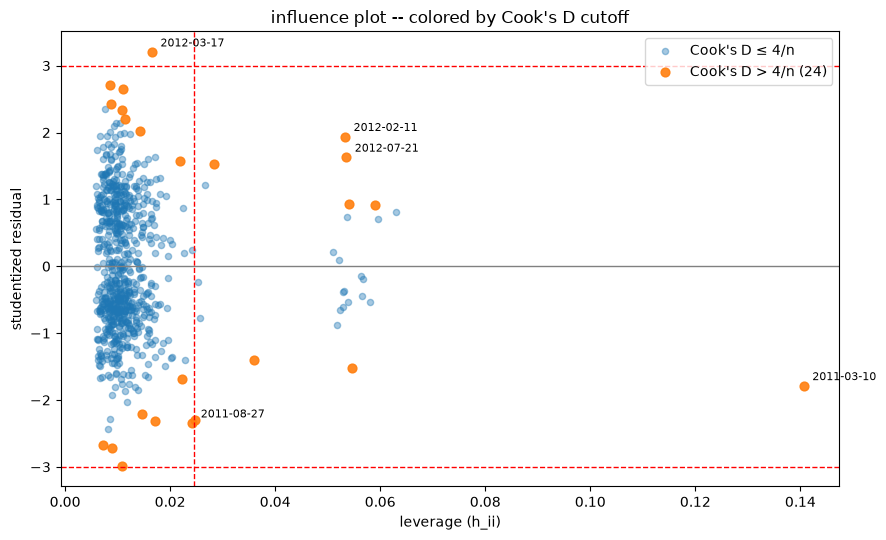

In [ ]:
# Plot all three at once: studentized residual vs. leverage, colored by Cook's D cutoff.
infl = diag.cooks_d > cook_cut

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(diag.leverage[~infl], diag.student_resid[~infl], s=20, alpha=0.4,
           color="tab:blue", label=f"Cook's D ≤ 4/n")
ax.scatter(diag.leverage[infl], diag.student_resid[infl], s=40, alpha=0.9,
           color="tab:orange", label=f"Cook's D > 4/n ({infl.sum()})")
ax.axhline(0, color="gray", lw=1)
for y in (-3, 3):
    ax.axhline(y, color="red", ls="--", lw=1)
ax.axvline(lev_cut, color="red", ls="--", lw=1)
ax.set(xlabel="leverage (h_ii)", ylabel="studentized residual",
       title="influence plot -- colored by Cook's D cutoff")
ax.legend()

for _, r in diag.nlargest(5, "cooks_d").iterrows():
    ax.annotate(r.date.strftime("%Y-%m-%d"), (r.leverage, r.student_resid),
                fontsize=8, xytext=(6, 4), textcoords="offset points")
plt.tight_layout()


2: [4 pts] In class, we built a model and looked at outliers, high leverage, and influential datapoints 
for the bike rental data set. We specifically identified 10/29/2012 as in the window for Hurricane 
Sandy. Given the model we have built, what happens to the coefficients if we remove this 
particular data point? What happens if we remove the data point from 2012-03-17, which meets 
the threshold for all three metrics? Would you remove either of these data points from your 
model, and if you did, how would you report on it to a stakeholder? 

ANSWER: Coefficients are affected when data points are signficant to the data such as outliers. 

Part 5: Feature Transformations (5 pts) We ran out of time for this in class, so this part of the lab will explore data transformations in more detail. 
You have already done one transformation in this course: the log-log model for the planets at the end of 
Lab 2. We also explored centering of the data in class when we looked at interaction terms.  

ANSWER: These readings have shown me the importance of feature transformations when it comes to preparing data for machine learning and statistical models. While reading these articles, I learned about different ways to transform features, including standardization, normalization, and log transformations. In addition, the readings discussed how the characteristics of the data and the model being used can impact which method should be used. This connects to our class discussion about bootstrapping because both involve being thoughtful about how we prepare and analyze our data. Feature transformations can put variables on a similar scale and improve model efficiency. I was also fascinated by how the results can be greatly impacted by the method of feature transformation. With that being said, my question is: How does one determine the best feature transformation for a dataset with outliers and highly skewed variables?